# Stroke Prediction Classification Project

This project aims to build a machine learning model to predict whether a patient is likely to experience a stroke based on healthcare-related features.

Since the target variable (`stroke`) contains two classes (0 = No Stroke, 1 = Stroke), this is a binary classification problem.

The workflow includes:
- Loading and exploring the dataset
- Performing exploratory data analysis (EDA)
- Handling missing values and preprocessing features
- Training multiple classification models
- Comparing models against a baseline
- Selecting the best-performing model based on an appropriate evaluation metric

## Import Required Libraries

The required Python libraries are imported for data manipulation, visualization, preprocessing, model training, and evaluation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

## Load Dataset

The healthcare stroke dataset is loaded using pandas.

The dataset contains patient information such as age, medical conditions, lifestyle factors, and the target variable (`stroke`), which indicates whether the patient experienced a stroke.

In [3]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")


## Initial Data Exploration

The dataset structure and statistical summary are examined to understand the available features, data types, and basic distributions.

This step helps identify:
- Numerical and categorical features
- Missing values
- Potential data quality issues

In [4]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [27]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


### Missing Values Analysis

Missing values were checked to identify incomplete records in the dataset.

In [4]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

### Handling Missing Values

The **BMI** feature contains **201 missing values**, which were identified during the data exploration phase.

To prevent **data leakage**, missing value imputation was performed later as part of the preprocessing pipeline rather than before splitting the data.

Since the BMI distribution contains potential outliers, the **median** was chosen for imputation because it is more robust to extreme values than the mean.

### Identify Categorical Features

The categorical features were identified during the exploratory data analysis phase. These features will later be encoded using One-Hot Encoding as part of the preprocessing pipeline.

In [ ]:
df.select_dtypes(include="str").columns

Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='str')

### Duplicate Records

Duplicate rows were checked to ensure that the dataset does not contain repeated patient records that could affect model performance.

In [28]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

EDA was performed to understand the distribution of features and explore relationships between patient characteristics and stroke occurrence.

The analysis includes:
- Target variable distribution
- Numerical feature distributions
- Categorical feature distributions
- Outlier analysis
- Feature correlation analysis

### Stroke Class Distribution

The target variable distribution was analyzed to understand the balance between stroke and non-stroke cases.

The dataset is highly imbalanced, as the number of non-stroke cases is significantly larger than stroke cases.

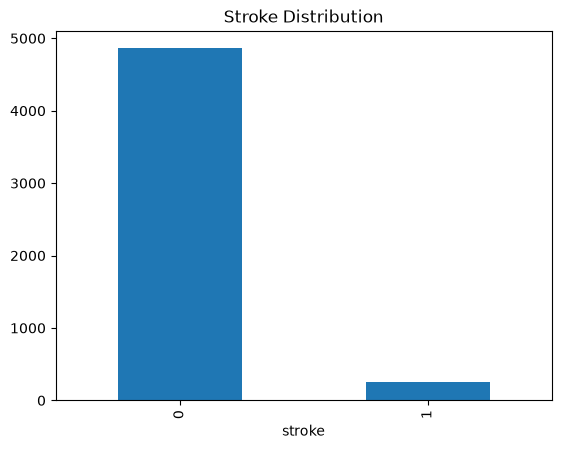

In [29]:
df["stroke"].value_counts().plot(kind="bar")

plt.title("Stroke Distribution")
plt.show()

The dataset is imbalanced because the number of stroke cases is much smaller than non-stroke cases.

In [31]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

### Age Distribution

The distribution of patient ages was visualized to better understand the age range and overall data distribution.

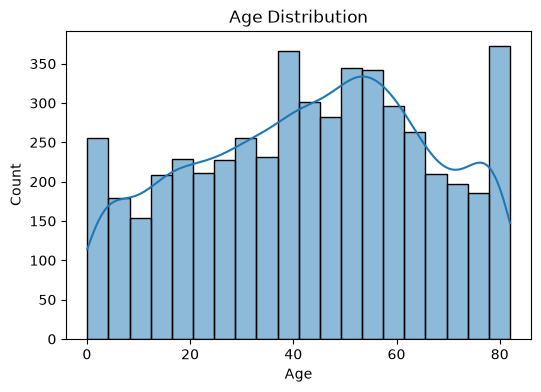

In [85]:
plt.figure(figsize=(6,4))

sns.histplot(df["age"], kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")

plt.show()

### BMI Distribution

The BMI distribution was explored to understand its spread and identify potential skewness or unusual values.

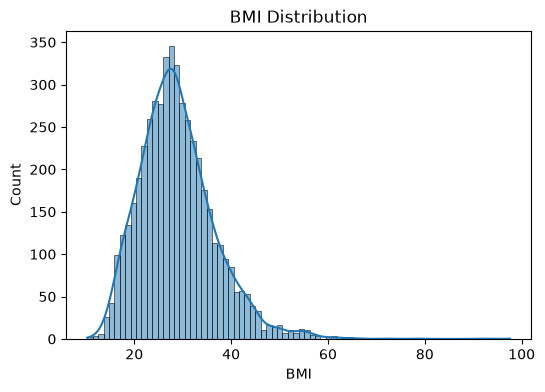

In [86]:
plt.figure(figsize=(6,4))

sns.histplot(
    df["bmi"],
    kde=True
)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")

plt.show()

### Average Glucose Level Distribution

The distribution of average glucose levels was examined to understand how this feature is distributed across patients.

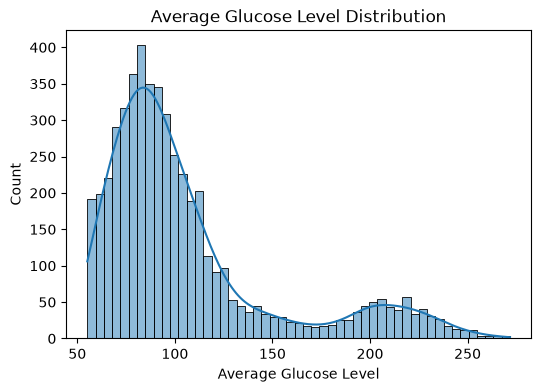

In [87]:
plt.figure(figsize=(6,4))

sns.histplot(
    df["avg_glucose_level"],
    kde=True
)

plt.title("Average Glucose Level Distribution")
plt.xlabel("Average Glucose Level")
plt.ylabel("Count")

plt.show()

### Gender Distribution

The distribution of patients by gender was explored to understand the composition of the dataset.

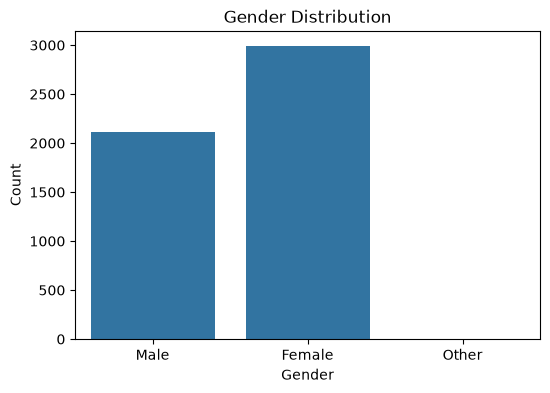

In [88]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="gender",
    data=df
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

### Smoking Status Distribution

The smoking status categories were explored to understand their frequency within the dataset.

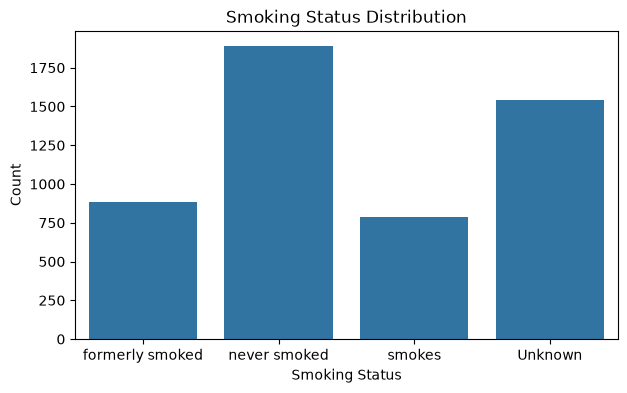

In [91]:
plt.figure(figsize=(7,4))

sns.countplot(
    x="smoking_status",
    data=df
)

plt.title("Smoking Status Distribution")
plt.xlabel("Smoking Status")
plt.ylabel("Count")

plt.show()

### BMI Outlier Analysis

A boxplot was used to identify potential outliers in the BMI feature.

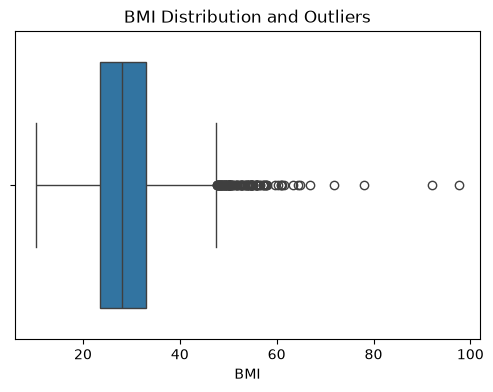

In [84]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df["bmi"])

plt.title("BMI Distribution and Outliers")
plt.xlabel("BMI")

plt.show()

### Age by Stroke Status

The relationship between patient age and stroke occurrence was explored using a boxplot.

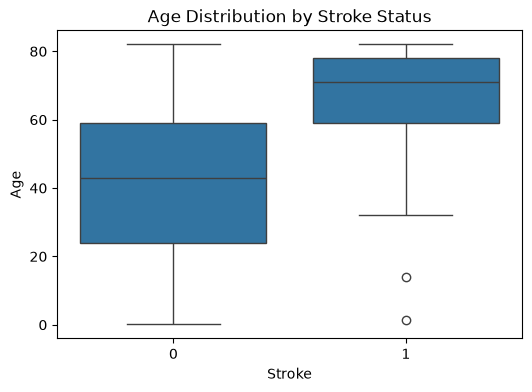

In [92]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="stroke",
    y="age",
    data=df
)

plt.title("Age Distribution by Stroke Status")
plt.xlabel("Stroke")
plt.ylabel("Age")

plt.show()

### Average Glucose Level by Stroke Status

The relationship between average glucose level and stroke occurrence was examined using a boxplot.

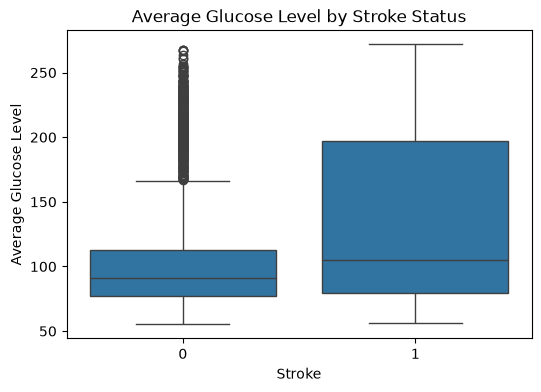

In [93]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="stroke",
    y="avg_glucose_level",
    data=df
)

plt.title("Average Glucose Level by Stroke Status")
plt.xlabel("Stroke")
plt.ylabel("Average Glucose Level")

plt.show()

### Hypertension and Stroke

The relationship between hypertension and stroke occurrence was explored using a grouped count plot.

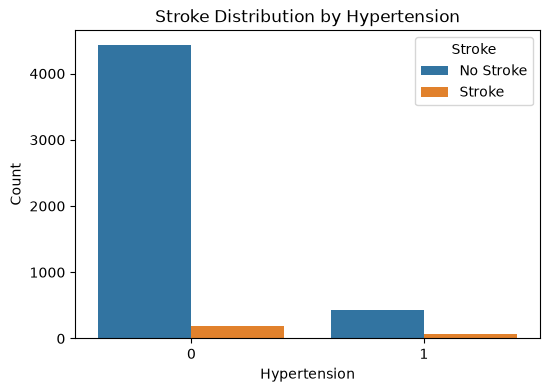

In [94]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="hypertension",
    hue="stroke",
    data=df
)

plt.title("Stroke Distribution by Hypertension")
plt.xlabel("Hypertension")
plt.ylabel("Count")

plt.legend(
    title="Stroke",
    labels=["No Stroke", "Stroke"]
)

plt.show()

The boxplot shows the presence of outliers in the BMI feature. Since this is a medical dataset, these values may represent real patient conditions (e.g., obesity) rather than data entry errors. Therefore, the outliers were retained and no outlier removal technique was applied.

### Feature Correlation Analysis

A correlation heatmap was created to analyze relationships between numerical features and the target variable.

The analysis shows that age has the strongest positive correlation with stroke, while other medical features such as hypertension and heart disease show weaker positive relationships.

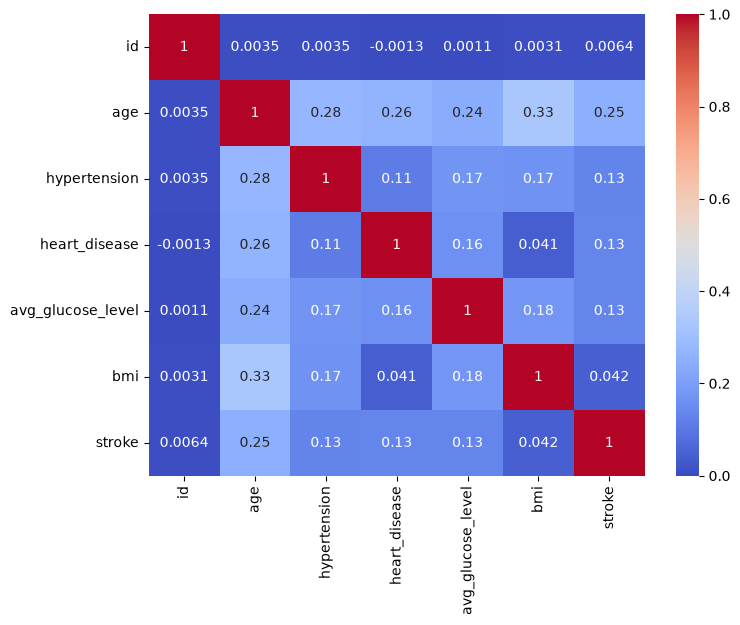

In [30]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

The correlation heatmap shows that age has the strongest positive correlation with stroke (≈0.25), suggesting that older individuals are more likely to experience a stroke. Other features such as hypertension, heart disease, and average glucose level show weak positive correlations, while BMI has a very weak relationship with the target.

## Data Preparation

The `id` column was removed because it is only an identifier and does not provide meaningful information for predicting stroke.

The dataset was then separated into:
- Features (`X`)
- Target variable (`y`)

In [17]:
df = df.drop("id", axis=1)

In [18]:
X = df.drop("stroke", axis=1)
y = df["stroke"]

## Train-Test Split

The dataset was divided into training and testing sets.

The training set is used to train the models, while the testing set is used to evaluate performance on unseen data.

Stratified splitting was applied to preserve the original class distribution because the dataset is imbalanced.

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Feature Groups

The features were divided into numerical and categorical groups so that the appropriate preprocessing techniques could be applied.

- Numerical features will be imputed (if needed) and scaled using `StandardScaler`.
- Categorical features will be encoded using `OneHotEncoder`.

In [13]:
categorical_features = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

numerical_features = [
    "age",
    "hypertension",
    "heart_disease",
    "avg_glucose_level",
    "bmi"
]

## Preprocessing Pipeline

A preprocessing pipeline was created to apply all required transformations consistently.

The pipeline includes:

- Median imputation for missing numerical values
- Feature scaling using StandardScaler
- One-hot encoding for categorical variables

Using a pipeline ensures that preprocessing steps are fitted only on the training data, preventing data leakage.

In [77]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numerical_features
        ),

        (
            "cat",
            Pipeline([
                ("encoder", OneHotEncoder(
                    drop="first",
                    handle_unknown="ignore"
                ))
            ]),
            categorical_features
        )
    ]
)

## Model Definition

Five classification models were prepared for training and comparison.

- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)

Each model uses the same preprocessing pipeline to ensure consistent feature transformations before training.

In [79]:
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight="balanced"
        ))
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced"
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
    random_state=42,
    class_weight="balanced_subsample",
    n_estimators=200
))
    ]),

    "SVM": Pipeline([
        ("preprocessor", preprocessor),
        ("model", SVC(
            random_state=42,
            class_weight="balanced"
        ))
    ]),

    "KNN": Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier())
    ])
}

## Model Training and Evaluation

Each model was trained using the training data and then evaluated on the test set.

For every model, the following were stored:
- Predicted labels
- Classification report
- Confusion matrix

These results were later used to compare model performance.

In [80]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results[name] = {
        "y_pred": y_pred,
        "report": classification_report(
            y_test,
            y_pred,
            output_dict=True
        ),
        "cm": confusion_matrix(y_test, y_pred)
    }

## Baseline Model

A Dummy Classifier was used as a baseline to compare the performance of machine learning models.

The baseline predicts the majority class for all samples. This provides a simple reference point to determine whether the trained models learn useful patterns from the data.

In [81]:
baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

baseline_report = classification_report(
    y_test,
    baseline_pred,
    output_dict=True,
    zero_division=0
)

## Model Evaluation and Comparison

The models were evaluated using classification metrics including:

- Accuracy
- Precision
- Recall
- F1-score

Because the dataset is highly imbalanced, Stroke Recall was considered the most important metric. Detecting actual stroke cases is more critical than achieving high overall accuracy.

In [ ]:
comparison = []

comparison.append({
    "Model": "Baseline (Most Frequent)",
    "Accuracy": baseline_report["accuracy"],
    "Stroke Precision": baseline_report["1"]["precision"],
    "Stroke Recall": baseline_report["1"]["recall"],
    "Stroke F1": baseline_report["1"]["f1-score"]
})


# Add ML models results
for name, result in results.items():

    report = result["report"]

    comparison.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Stroke Precision": report["1"]["precision"],
        "Stroke Recall": report["1"]["recall"],
        "Stroke F1": report["1"]["f1-score"]
    })


comparison_df = pd.DataFrame(comparison)

comparison_df.sort_values(
    by="Stroke Recall",
    ascending=False
)

,Model,Accuracy,Stroke Precision,Stroke Recall,Stroke F1
1,Logistic Regression,0.745597,0.137931,0.80,0.235294
4,SVM,0.755382,0.137681,0.76,0.233129
2,Decision Tree,0.929550,0.156250,0.10,0.121951
5,KNN,0.943249,0.100000,0.02,0.033333
0,Baseline (Most Frequent),0.951076,0.000000,0.00,0.000000
3,Random Forest,0.950098,0.000000,0.00,0.000000


## Confusion Matrix Analysis

Confusion matrices were generated to better understand model predictions.

They show:
- Correct predictions
- False positives
- False negatives

For this healthcare problem, reducing false negatives is important because missing a stroke case can have serious consequences.

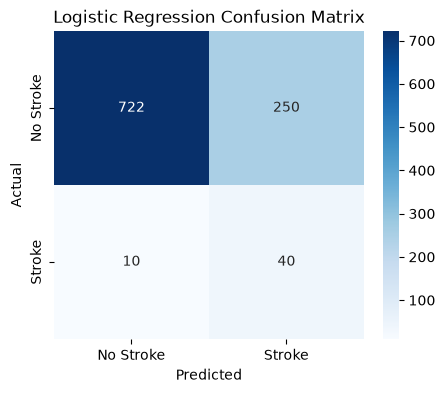

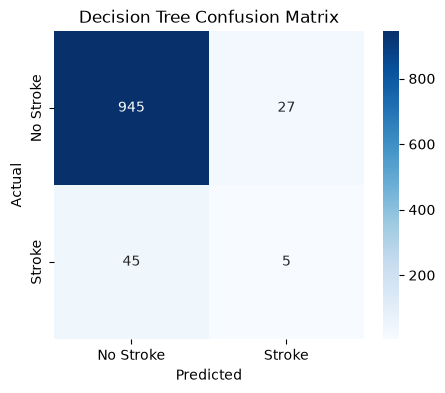

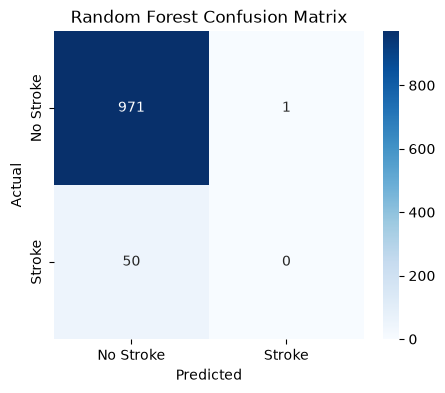

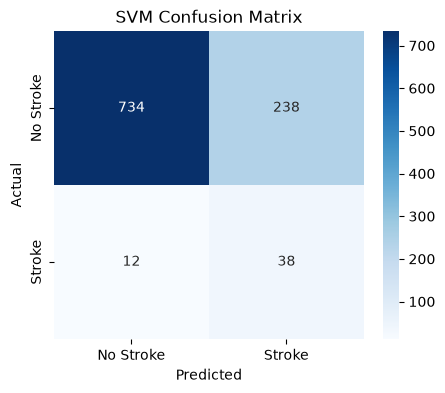

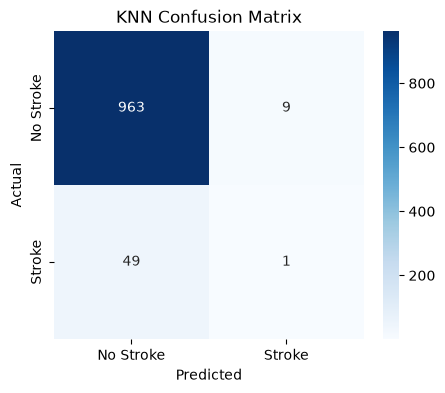

In [73]:
for name, result in results.items():

    plt.figure(figsize=(5,4))

    sns.heatmap(
        result["cm"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Stroke", "Stroke"],
        yticklabels=["No Stroke", "Stroke"]
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

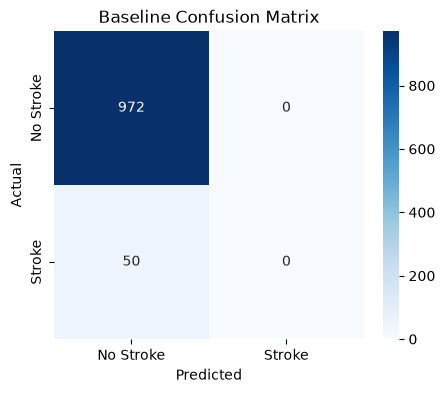

In [74]:
baseline_cm = confusion_matrix(
    y_test,
    baseline_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    baseline_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Stroke", "Stroke"],
    yticklabels=["No Stroke", "Stroke"]
)

plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Baseline Comparison

A Dummy Classifier was used as a baseline model to compare the performance of the trained classification models.

The baseline predicts the majority class (`stroke = 0`) for all samples. Although it achieved a high accuracy of 95%, it failed to detect any stroke cases, resulting in a recall of 0% for the stroke class.

This happens because the dataset is highly imbalanced, where non-stroke cases represent the majority of the data.

Compared with the baseline, Logistic Regression achieved a significantly higher recall for stroke cases (80%), showing that it learned useful patterns from the features and was able to identify patients with a higher risk of stroke.

Therefore, accuracy alone is not a suitable metric for this healthcare problem, and recall for the stroke class was considered the main evaluation metric.

## Model Selection and Evaluation

The dataset is highly imbalanced, where the number of non-stroke cases is much higher than stroke cases. Therefore, accuracy alone is not a reliable metric for evaluating model performance.

For this problem, **Stroke Recall** is considered the most important metric because it measures the ability of the model to correctly identify patients who actually have a stroke. Missing a stroke case (False Negative) is more critical than incorrectly predicting stroke for a healthy person.

### Model Comparison

Based on the evaluation results:

- **Logistic Regression** achieved the highest Stroke Recall (**80%**), meaning it successfully detected most of the actual stroke cases.
- **SVM** also performed well with a Stroke Recall of **76%**, making it a strong alternative.
- Although **Random Forest**, **Decision Tree**, and **KNN** achieved higher accuracy values, their Stroke Recall was significantly lower. This means they correctly classified most non-stroke cases but failed to detect many stroke patients.

### Why Logistic Regression Was Selected?

Logistic Regression was selected as the best model because it provided the best performance for the main objective of this healthcare problem: detecting stroke cases.

Using `class_weight="balanced"` helped the model handle the class imbalance by giving more importance to the minority class (`stroke = 1`). As a result, the model became more sensitive to stroke cases and achieved a higher recall.

For example:

- Logistic Regression detected **80%** of stroke cases.
- Random Forest detected only **10%** of stroke cases despite having higher accuracy.

Therefore, Logistic Regression is more suitable for this dataset because it reduces the risk of missing patients who may actually have a stroke.